In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
pd.set_option('display.max_columns',100)

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import HistGradientBoostingClassifier



In [2]:
# Loading prepared Dataset for Model Training
df=pd.read_csv("Datasets/ipl_prediction.csv")
df.head()

,match_id,batting_team,bowling_team,city,runs_left,balls_left,wickets,total_runs_x,crr,rrr,winner
0,212,Rajasthan Royals,Kings XI Punjab,Jaipur,58,70,10,153,11.520000,4.971429,Rajasthan Royals
1,172,Sunrisers Hyderabad,Delhi Capitals,Centurion,17,36,6,153,9.785714,2.833333,Deccan Chargers
2,452,Chennai Super Kings,Royal Challengers Bangalore,Bangalore,40,78,6,106,9.571429,3.076923,Royal Challengers Bangalore
3,380,Delhi Capitals,Chennai Super Kings,Chennai,175,82,8,222,7.578947,12.804878,Chennai Super Kings
4,1,Royal Challengers Bangalore,Sunrisers Hyderabad,Hyderabad,82,43,6,207,9.818182,11.441860,Sunrisers Hyderabad


In [3]:
X = df.drop(columns=['winner', 'match_id'])
y = df['winner']

In [4]:
import pickle
le_dict = {}

for col in X.columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    le_dict[col] = le

# encode target
le_y = LabelEncoder()
y = le_y.fit_transform(y)
pickle.dump(le_dict, open("encoder.pkl", "wb"))
pickle.dump(le_y, open("target_encoders.pkl", "wb"))

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "Extra Trees": ExtraTreesClassifier(n_estimators=50,max_depth=8,min_samples_split=10,min_samples_leaf=5,random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "XGBoost": XGBClassifier(eval_metric='mlogloss'),
    "LightGBM": LGBMClassifier(),
    "HistGradientBoosting":HistGradientBoostingClassifier(max_depth=6)
}

In [17]:
results = []

for name, model in models.items():
    
    # Cross-validation score
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)
    cv_acc = cv_scores.mean()
    
    # Train on full training data
    model.fit(X_train, y_train)
    
    # Test prediction
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results.append([name, cv_acc, acc, f1])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000477 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1075
[LightGBM] [Info] Number of data points in the train set: 46172, number of used features: 9
[LightGBM] [Info] Start training from score -1.888179
[LightGBM] [Info] Start training from score -3.201102
[LightGBM] [Info] Start training from score -4.112087
[LightGBM] [Info] Start training from score -2.430944
[LightGBM] [Info] Start training from score -2.155277
[LightGBM] [Info] Start training from score -2.047303
[LightGBM] [Info] Start training from score -1.824562
[LightGBM] [Info] Start training from score -2.191437
[LightGBM] [Info] Start training from score -2.228753
[LightGBM] [Info] Start training from score -2.551718
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001624 seconds.
You 

In [18]:
results_df = pd.DataFrame(results, columns=[
    "Model", "CV Accuracy", "Test Accuracy", "F1 Score"
])

In [19]:
results_df

,Model,CV Accuracy,Test Accuracy,F1 Score
0,Random Forest,0.999116,0.998683,0.998682
1,Extra Trees,0.865046,0.869776,0.863835
2,Logistic Regression,0.263445,0.272299,0.202032
3,XGBoost,0.999653,0.999653,0.999653
4,LightGBM,0.999723,0.999723,0.999723
5,HistGradientBoosting,0.999532,0.999723,0.999723


In [21]:
safe_models =  ["Extra Trees","HistGradientBoosting"]

filtered_df = results_df[results_df["Model"].isin(safe_models)]

best_model_name = filtered_df.sort_values(
    by="F1 Score", ascending=False
).iloc[0]["Model"]

best_model = models[best_model_name]
best_model

HistGradientBoostingClassifier(max_depth=6)

In [22]:
with open("Models/best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

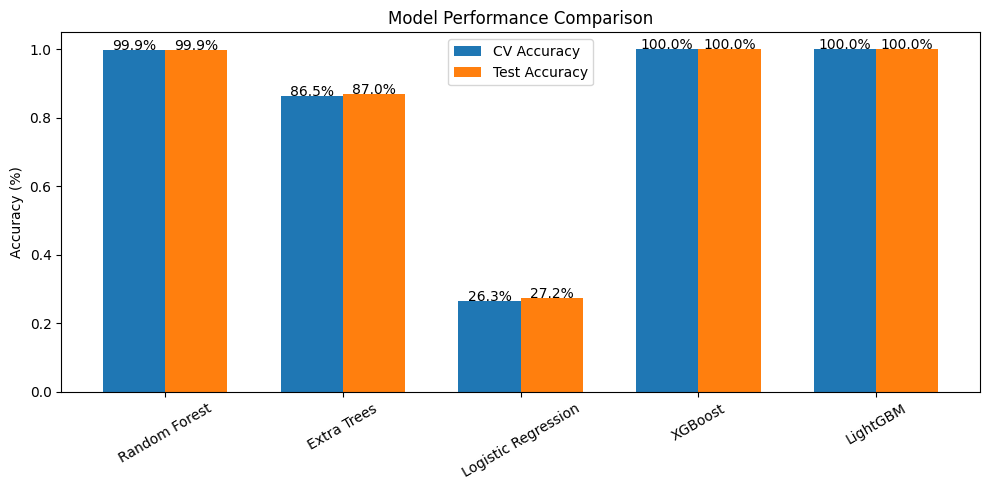

In [12]:
x = np.arange(len(results_df["Model"]))
width = 0.35

plt.figure(figsize=(10,5))

bars1 = plt.bar(x - width/2, results_df["CV Accuracy"], width, label="CV Accuracy")
bars2 = plt.bar(x + width/2, results_df["Test Accuracy"], width, label="Test Accuracy")

plt.xticks(x, results_df["Model"], rotation=30)
plt.ylabel("Accuracy (%)")
plt.title("Model Performance Comparison")

# 🔥 Add values on top (Instagram style)
for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{bar.get_height()*100:.1f}%", ha='center')

for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{bar.get_height()*100:.1f}%", ha='center')

plt.legend()
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=300)
plt.show()

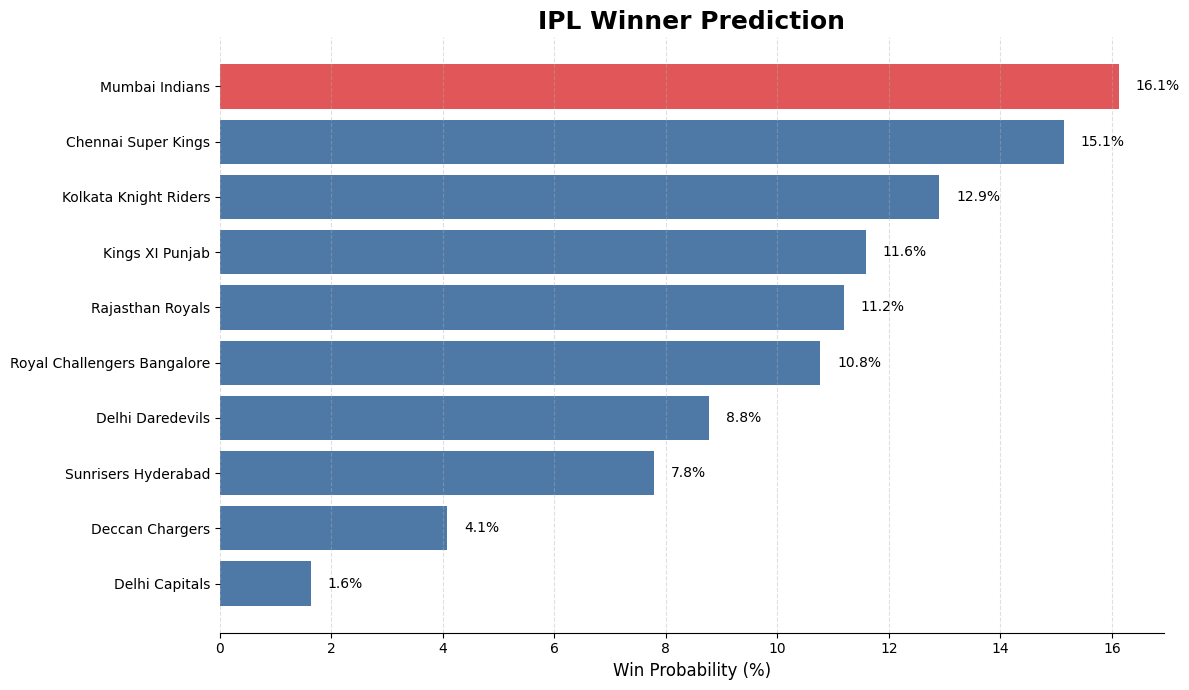

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(12,7))

teams = le_y.classes_
probs = model.predict_proba(X_test)
avg_probs = np.mean(probs, axis=0) * 100

prob_df = pd.DataFrame({
    "Team": teams,
    "Win Probability": avg_probs
}).sort_values(by="Win Probability", ascending=True)

# 🎯 Professional color palette
base_color = "#4E79A7"      # soft blue
highlight_color = "#E15759" # premium red

# Highlight top team
max_index = prob_df["Win Probability"].idxmax()

colors = [
    highlight_color if i == max_index else base_color
    for i in prob_df.index
]

# Plot
bars = plt.barh(prob_df["Team"], prob_df["Win Probability"], 
                color=colors)

# Title
plt.title("IPL Winner Prediction", fontsize=18, fontweight='bold')

# Labels
plt.xlabel("Win Probability (%)", fontsize=12)

# Remove unnecessary borders
plt.gca().spines[['top','right','left']].set_visible(False)

# Subtle grid
plt.grid(axis='x', linestyle='--', alpha=0.4)

# Value labels
for i, v in enumerate(prob_df["Win Probability"]):
    plt.text(v + 0.3, i, f"{v:.1f}%", 
             va='center', fontsize=10, fontweight='medium')

plt.tight_layout()
plt.savefig("linkedin_ip_prediction.png", dpi=300, bbox_inches='tight')
plt.show()

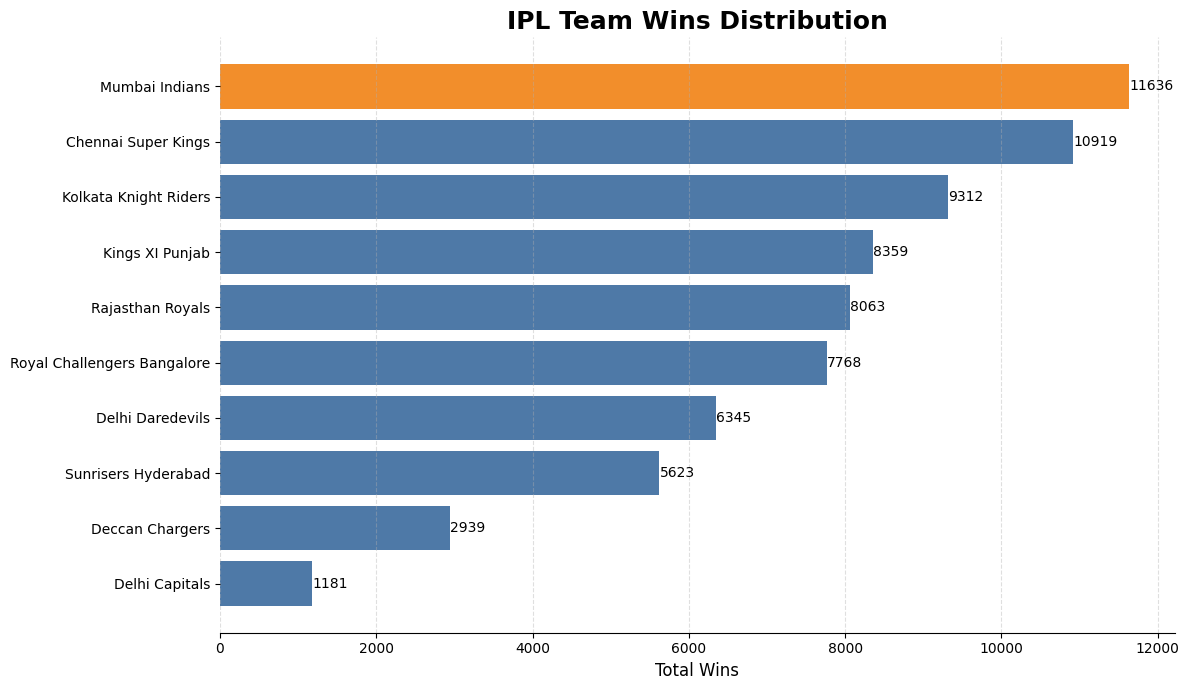

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

win_counts = df['winner'].value_counts().sort_values(ascending=True)

plt.figure(figsize=(12,7))

# 🎯 Professional colors
base_color = "#4E79A7"      # soft blue
highlight_color = "#F28E2B" # elegant orange

# Highlight top team
max_value = win_counts.max()

colors = [
    highlight_color if v == max_value else base_color
    for v in win_counts.values
]

# Plot
bars = plt.barh(win_counts.index, win_counts.values, color=colors)

# Title
plt.title("IPL Team Wins Distribution", fontsize=18, fontweight='bold')

# Labels
plt.xlabel("Total Wins", fontsize=12)

# Clean look
plt.gca().spines[['top','right','left']].set_visible(False)
plt.grid(axis='x', linestyle='--', alpha=0.4)

# Value labels
for i, v in enumerate(win_counts.values):
    plt.text(v + 2, i, str(v),
             va='center', fontsize=10, fontweight='medium')

plt.tight_layout()
plt.savefig("linkedin_team_wins.png", dpi=300, bbox_inches='tight')
plt.show()